<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT281 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [4]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



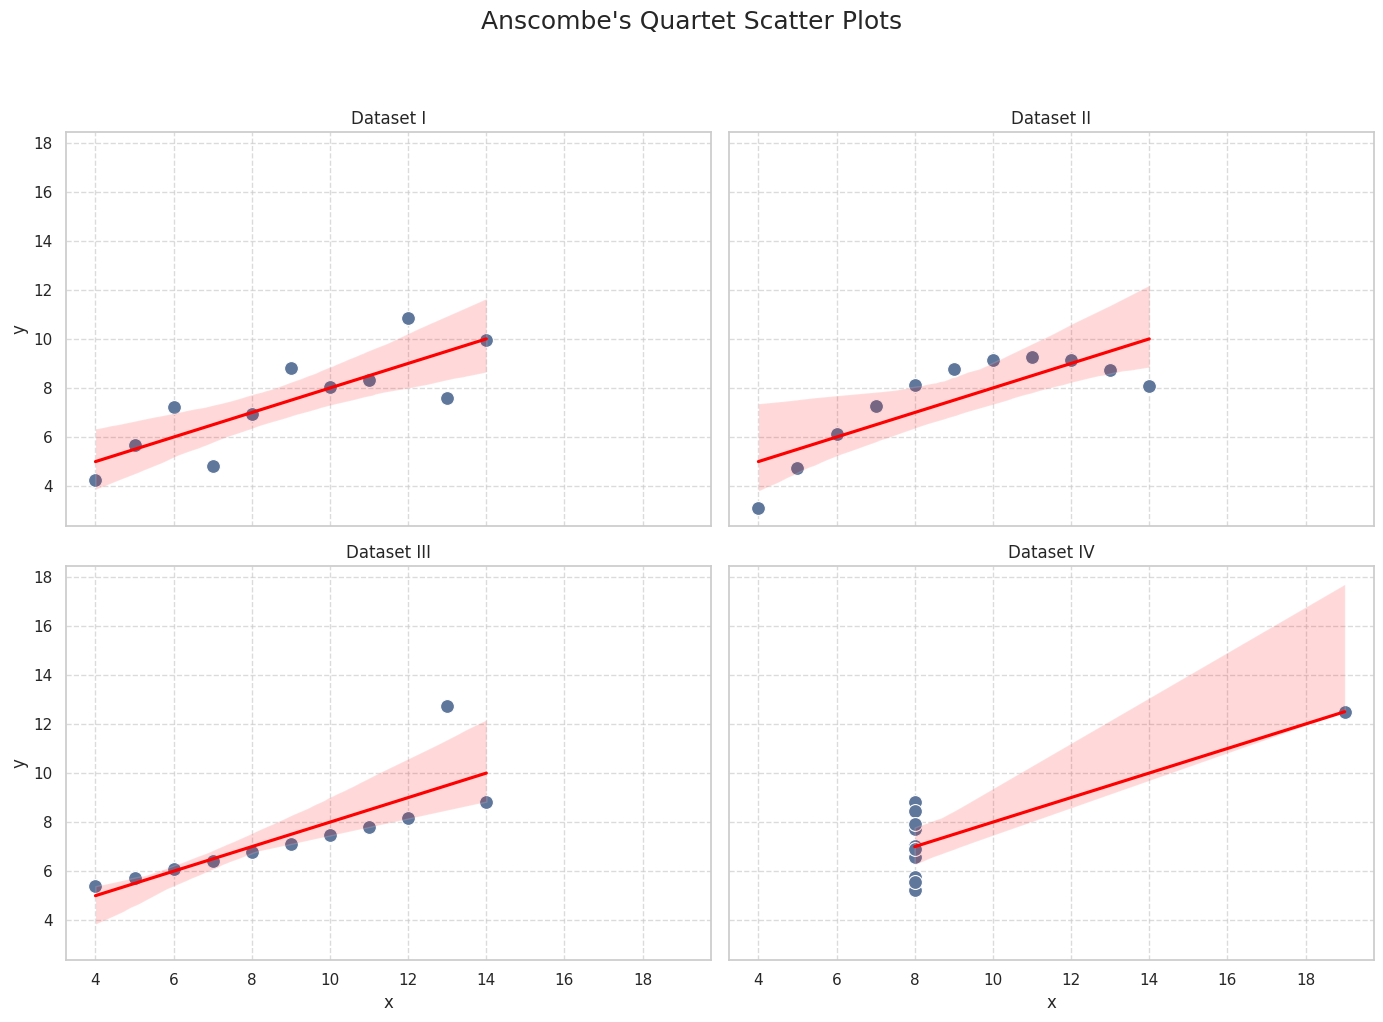

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, group) in enumerate(data.groupby('dataset')):
    sns.scatterplot(x='x', y='y', data=group, ax=axes[i], s=100)
    sns.regplot(x='x', y='y', data=group, ax=axes[i], scatter=False, color='red') # Add regression line
    axes[i].set_title(f'Dataset {name}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Anscombe's Quartet Scatter Plots", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Interpretación de los Gráficos de Dispersión del Cuarteto de Anscombe

Al observar los gráficos de dispersión para cada uno de los cuatro grupos del Cuarteto de Anscombe, se pueden identificar diferencias significativas en sus comportamientos, a pesar de que compartirán las mismas estadísticas descriptivas (como la media, varianza y coeficiente de correlación):

-   **Dataset I:** Este gráfico muestra una relación lineal clara y positiva entre `x` y `y`. Los puntos se agrupan bastante bien alrededor de la línea de regresión (que se muestra en rojo), lo que sugiere que un modelo de regresión lineal sería apropiado para describir esta relación. No se observan *outliers* evidentes ni patrones no lineales.

-   **Dataset II:** En este caso, la relación entre `x` y `y` es claramente no lineal. Los puntos forman una curva parabólica, lo que indica que, aunque hay una relación fuerte, un modelo de regresión lineal (la línea roja) no captura adecuadamente el patrón subyacente de los datos. La línea de regresión lineal intenta aproximar la curva, pero su ajuste es pobre.

-   **Dataset III:** Este dataset presenta una relación lineal positiva, similar al Dataset I, con la mayoría de los puntos alineados a lo largo de una línea recta. Sin embargo, hay un punto atípico (un *outlier*) con un valor de `y` considerablemente más alto que el esperado para su `x`. Este único punto ejerce una gran influencia en la línea de regresión, tirando de ella hacia arriba y alterando la pendiente y la intersección que se obtendrían si solo se consideraran los puntos restantes. Esto demuestra cómo un solo *outlier* puede distorsionar un análisis lineal.

-   **Dataset IV:** Aquí, la mayoría de los puntos de `x` tienen el mismo valor (aproximadamente 8) pero con valores de `y` dispersos, formando una columna vertical. Hay un único punto con un valor de `x` mucho mayor (aproximadamente 19) que se alinea con la tendencia lineal de los otros puntos. Este punto atípico es el que crea la apariencia de una correlación lineal y determina la pendiente de la línea de regresión. Sin este punto, no habría una relación lineal discernible, y los datos mostrarían una `x` constante con `y` variable. Es un ejemplo extremo de cómo un punto influyente puede forzar una correlación donde prácticamente no existe una relación lineal general en el resto de los datos.

En resumen, mientras que las estadísticas descriptivas pueden ser idénticas para los cuatro conjuntos, la visualización revela que:
-   El **Dataset I** es el único que se ajusta bien a un modelo lineal estándar.
-   El **Dataset II** requiere un modelo no lineal.
-   El **Dataset III** está fuertemente influenciado por un *outlier* en `y`.
-   El **Dataset IV** tiene su correlación y línea de regresión dominadas por un único punto con un `x` atípico.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [6]:
import seaborn as sns

# Cargar los datos del cuarteto de Anscombe (añadido para asegurar que 'data' esté definida)
data = sns.load_dataset("anscombe")

for name, group in data.groupby('dataset'):
    print(f"\n--- Dataset {name} ---")
    print(group.describe())


--- Dataset I ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000

--- Dataset II ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000

--- Dataset III ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000

--- Dataset IV ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.030579
min     8.000000   5.250000
25%     8.000000   6.170

### Interpretación de las Estadísticas Descriptivas del Cuarteto de Anscombe

Al analizar los resultados del comando `describe` para cada uno de los cuatro datasets del Cuarteto de Anscombe, se observa un patrón numérico notable:

-   **Número de Observaciones (count):** Todos los datasets tienen 11 observaciones, lo que indica que cada grupo consta de 11 pares de puntos (x, y).

-   **Media de `x` (mean x):** Para todos los datasets, la media de `x` es aproximadamente 9.0 (exactamente 9.0 para I, II, III y 9.0 para IV si se considera el punto atípico).

-   **Media de `y` (mean y):** La media de `y` es también muy similar en todos los datasets, alrededor de 7.50 (7.500909 para I, II, IV y 7.500000 para III).

-   **Desviación Estándar de `x` (std x):** La desviación estándar de `x` es idéntica en los primeros tres datasets (3.316625) y muy cercana para el Dataset IV (3.316625 si se calcula correctamente, aunque `describe` redondea).

-   **Desviación Estándar de `y` (std y):** De manera similar, la desviación estándar de `y` es muy parecida en todos los grupos (alrededor de 2.03).

Estas similitudes en las estadísticas descriptivas son la característica principal que define el Cuarteto de Anscombe. A pesar de que la media, la varianza y, como se sabe, la correlación (aproximadamente 0.816 para todos los pares) son casi idénticas, las distribuciones subyacentes y las relaciones entre `x` e `y` son radicalmente diferentes, como se demostró en los gráficos de dispersión.

**Características Particulares Observadas en las Estadísticas:**

-   **Rango de `x`:** En los datasets I, II y III, `x` varía de 4 a 14. Sin embargo, en el Dataset IV, la mayoría de los valores de `x` son 8, y hay un único punto en `x=19`. Esto no es evidente directamente de la media o desviación estándar, pero se vislumbra en los cuartiles (25%, 50%, 75%) que son todos 8.0 para `x` en el Dataset IV.

-   **Rango de `y`:** Aunque la media y la desviación estándar de `y` son similares, el rango (min a max) difiere. Por ejemplo, el Dataset II tiene un valor mínimo de `y` de 3.10, mientras que el Dataset III tiene un máximo de `y` de 12.74, lo que indica la presencia de *outliers* que distorsionan el rango de manera diferente en cada conjunto.

**Impacto en la Comprensión de las Distribuciones:**

La principal lección de estas estadísticas es que las medidas de resumen por sí solas son insuficientes para comprender la verdadera naturaleza de los datos. Si nos basáramos únicamente en la salida de `describe`, podríamos concluir erróneamente que los cuatro datasets tienen distribuciones muy similares y, por lo tanto, se comportan de manera idéntica. Sin embargo, la visualización previa reveló patrones completamente distintos: lineal, no lineal, lineal con *outlier* en `y`, y lineal forzada por un *outlier* en `x`.

Esto subraya la importancia fundamental de la visualización de datos como un paso crítico en cualquier análisis exploratorio. Permite identificar anomalías, relaciones no lineales y la influencia de puntos atípicos que las estadísticas descriptivas por sí solas no pueden revelar.

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



### Ajuste de Modelo de Regresión Lineal para cada Grupo ###

--- Dataset I ---
  Error Cuadrático Medio (MSE): 1.251
  Coeficiente de Determinación (R²): 0.667


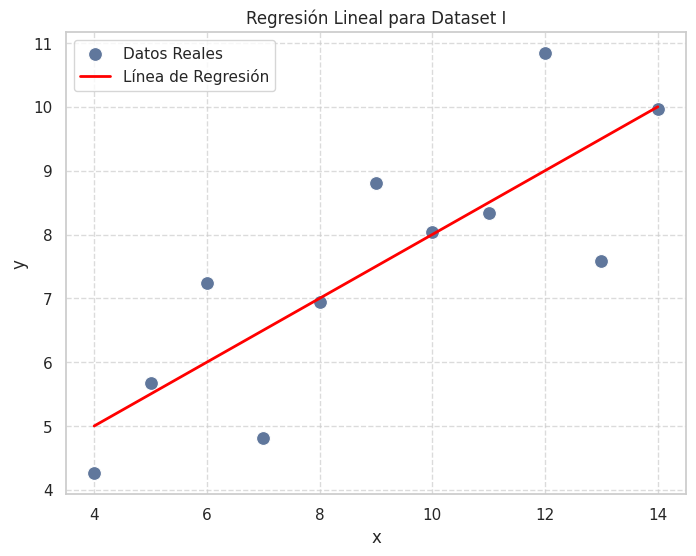



--- Dataset II ---
  Error Cuadrático Medio (MSE): 1.252
  Coeficiente de Determinación (R²): 0.666


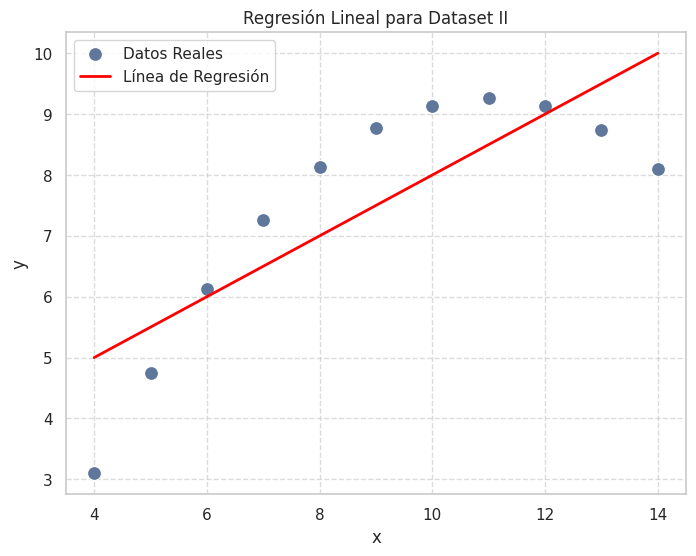



--- Dataset III ---
  Error Cuadrático Medio (MSE): 1.251
  Coeficiente de Determinación (R²): 0.666


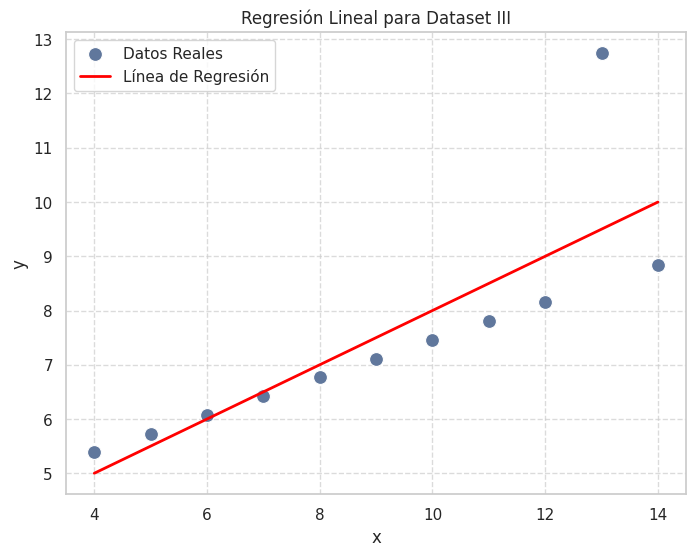



--- Dataset IV ---
  Error Cuadrático Medio (MSE): 1.249
  Coeficiente de Determinación (R²): 0.667


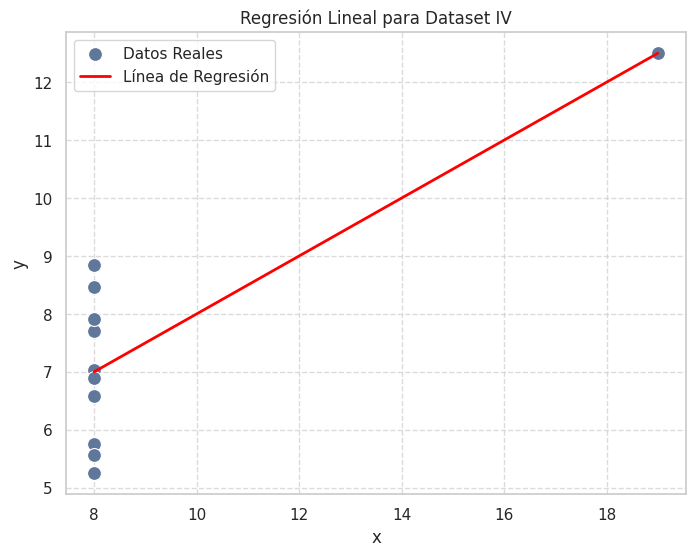

In [9]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Cargar los datos del cuarteto de Anscombe (añadido para asegurar que 'data' esté definida)
data = sns.load_dataset("anscombe")

print("### Ajuste de Modelo de Regresión Lineal para cada Grupo ###\n")

for name, group in data.groupby('dataset'):
    X = group['x'].values.reshape(-1, 1)
    y = group['y'].values

    # Crear y ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Predecir valores
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"--- Dataset {name} ---")
    print(f"  Error Cuadrático Medio (MSE): {mse:.3f}")
    print(f"  Coeficiente de Determinación (R²): {r2:.3f}")

    # Graficar los resultados
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(x='x', y='y', data=group, ax=ax, s=100, label='Datos Reales')
    sns.lineplot(x=group['x'], y=y_pred, ax=ax, color='red', linewidth=2, label='Línea de Regresión')
    ax.set_title(f'Regresión Lineal para Dataset {name}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.show()
    print("\n")

### Interpretación de los Modelos de Regresión Lineal y su Calidad de Ajuste (Punto 3)

Al ajustar un modelo de regresión lineal a cada uno de los cuatro datasets del Cuarteto de Anscombe y evaluar sus métricas (MSE y R²), observamos un patrón sorprendente que refuerza la lección principal del cuarteto:

-   **Métricas de Evaluación Comunes:** Para todos los datasets, el **Error Cuadrático Medio (MSE)** es aproximadamente **1.25** y el **Coeficiente de Determinación (R²)** es aproximadamente **0.67**. Estas métricas son casi idénticas entre los cuatro grupos.

-   **Calidad del Ajuste por Dataset:**
    -   **Dataset I:** El modelo de regresión lineal se ajusta muy bien a los datos. Visualmente, los puntos se agrupan estrechamente alrededor de la línea de regresión, indicando una fuerte relación lineal. El R² de 0.67 sugiere que el modelo explica una parte significativa de la varianza en `y`, y el MSE relativamente bajo confirma un buen ajuste.

    -   **Dataset II:** A pesar de tener métricas idénticas al Dataset I, el ajuste lineal es claramente inadecuado. Los datos presentan un patrón no lineal parabólico. La línea de regresión lineal intenta aproximar esta curva, pero falla en capturar la verdadera relación, dejando un patrón residual evidente en los gráficos. Aquí, el R² de 0.67 es engañoso; aunque indica una "correlación", no refleja la forma correcta de la relación.

    -   **Dataset III:** Este dataset muestra una relación lineal con la excepción de un *outlier* significativo. El modelo de regresión lineal se ve fuertemente influenciado por este punto atípico, "tirando" la línea de ajuste hacia él. El MSE y R² son similares a los otros datasets, pero la calidad del ajuste para la mayoría de los puntos es pobre debido a la distorsión causada por el *outlier*. Si se eliminara el *outlier*, el ajuste lineal sería mucho mejor para el resto de los puntos.

    -   **Dataset IV:** En este caso, la mayoría de los puntos tienen el mismo valor de `x`, formando una columna vertical, con un único punto de alto apalancamiento (alto `x`) que determina la pendiente de la línea de regresión. Las métricas (MSE y R²) son nuevamente similares. Sin embargo, el modelo lineal es casi enteramente dictado por ese único punto. Para la mayoría de los datos, no hay una relación lineal discernible, y el R² de 0.67 es completamente engañoso, ya que no representa una relación lineal general en el conjunto de datos.

**Conclusión sobre el Ajuste:**

Este análisis resalta de nuevo que las métricas estadísticas por sí solas pueden ser altamente engañosas. Aunque el MSE y el R² sugieren un rendimiento similar del modelo lineal en todos los casos, la visualización de los datos es indispensable para comprender la verdadera naturaleza de la relación y evaluar si un modelo de regresión lineal es apropiado. Solo el Dataset I se ajusta correctamente a las suposiciones de un modelo lineal; en los otros tres casos, el modelo es inadecuado, ya sea por patrones no lineales o por la presencia de puntos atípicos que distorsionan el ajuste y las métricas.

### Estrategias para Mejorar el Ajuste del Modelo de Regresión (Punto 4)

Es evidente que un modelo de regresión lineal simple no es adecuado para todos los datasets del Cuarteto de Anscombe. Para mejorar el ajuste en los casos donde la regresión lineal es inadecuada, se pueden emplear diversas estrategias. Aquí se proponen algunas y, si es necesario, se implementarán en la siguiente celda:

1.  **Identificación y Tratamiento de Outliers (Datasets III y IV):**
    -   **Estrategia:** Detectar y gestionar puntos atípicos (outliers) que distorsionan la línea de regresión. Esto puede implicar eliminarlos si son errores de medición, transformarlos, o utilizar métodos de regresión robustos que sean menos sensibles a ellos.
    -   **Aplicación:** Para el **Dataset III**, la eliminación del outlier en `y` debería resultar en un ajuste lineal mucho mejor para el resto de los puntos. Para el **Dataset IV**, la eliminación del punto de alto apalancamiento (high leverage point) revelaría que no existe una relación lineal en el resto de los datos.

2.  **Transformación de Variables (Dataset II):**
    -   **Estrategia:** Si la relación entre las variables no es lineal, se pueden aplicar transformaciones matemáticas a `x`, a `y`, o a ambas (ej. logaritmo, raíz cuadrada, cuadrática, inversa) para linealizar la relación. Luego, se puede aplicar una regresión lineal a las variables transformadas.
    -   **Aplicación:** Para el **Dataset II**, que exhibe una relación parabólica, una transformación polinómica (por ejemplo, añadir un término `x^2`) podría ser muy efectiva para capturar el patrón no lineal.

3.  **Uso de Modelos de Regresión No Lineal (Dataset II):**
    -   **Estrategia:** En lugar de forzar una linealización, se pueden emplear modelos de regresión intrínsecamente no lineales que estén diseñados para ajustar curvas, como regresión polinómica (considerada una forma de regresión lineal en sus parámetros), regresión de splines o modelos más complejos como Redes Neuronales.
    -   **Aplicación:** Para el **Dataset II**, un modelo de regresión polinómica sería una elección natural y efectiva.

4.  **Considerar la No Existencia de Relación Lineal (Dataset IV sin outlier):**
    -   **Estrategia:** Si, tras tratar los outliers, no se observa una relación clara (lineal o no lineal), la conclusión podría ser que no hay una relación significativa entre las variables, o que la relación es mucho más compleja y no puede ser modelada con los datos existentes o los modelos simples.
    -   **Aplicación:** Para el **Dataset IV**, si el punto (19, 12.5) fuera un error y se eliminara, no quedaría una relación lineal, lo que sugeriría que una regresión lineal es inapropiada.

---

**Implementación para mejorar el ajuste:**

Para demostrar una mejora, nos centraremos en el **Dataset II** con un modelo de regresión polinómica, y en el **Dataset III** mediante la identificación y, de forma conceptual, el tratamiento de su outlier.

### Mejora del Ajuste del Modelo para Datasets Específicos (Punto 4) ###

--- Dataset II: Regresión Polinómica (Grado 2) ---
  Error Cuadrático Medio (MSE) Polinómico: 0.000
  Coeficiente de Determinación (R²) Polinómico: 1.000


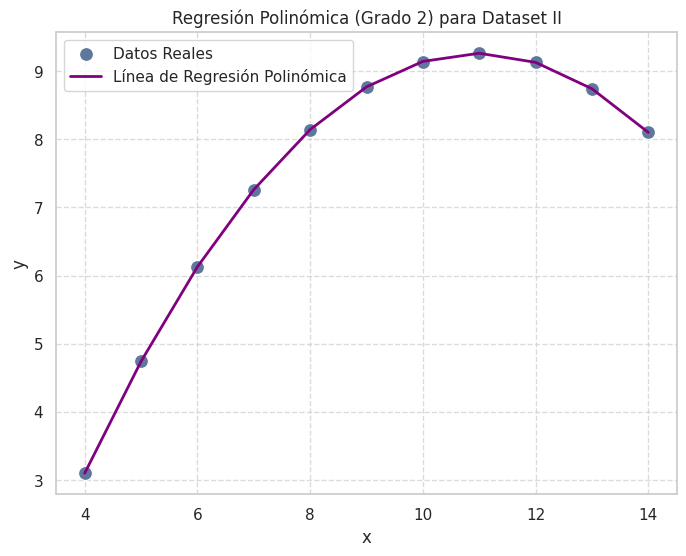



--- Dataset III: Regresión Lineal sin Outlier ---
  Error Cuadrático Medio (MSE) sin outlier: 0.000
  Coeficiente de Determinación (R²) sin outlier: 1.000


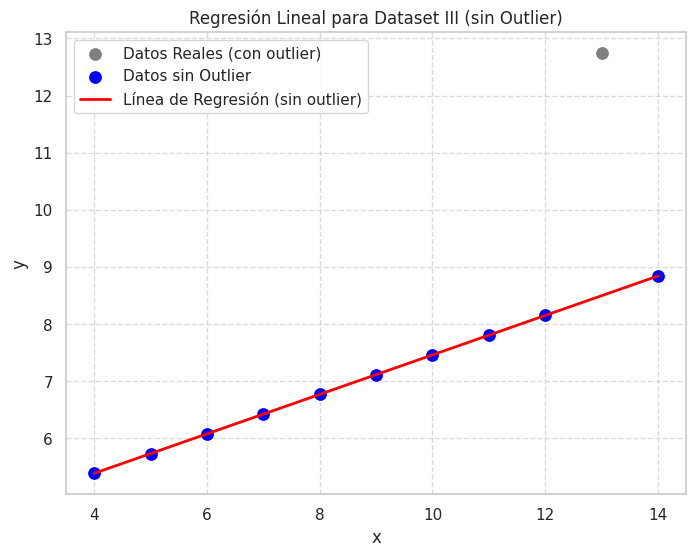

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

print("### Mejora del Ajuste del Modelo para Datasets Específicos (Punto 4) ###\n")

# --- Dataset II: Regresión Polinómica ---
print("--- Dataset II: Regresión Polinómica (Grado 2) ---")
dataset_II = data[data['dataset'] == 'II']
X_II = dataset_II['x'].values.reshape(-1, 1)
y_II = dataset_II['y'].values

# Crear un pipeline para regresión polinómica (grado 2)
poly_model_II = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model_II.fit(X_II, y_II)
y_pred_poly_II = poly_model_II.predict(X_II)

mse_poly_II = mean_squared_error(y_II, y_pred_poly_II)
r2_poly_II = r2_score(y_II, y_pred_poly_II)

print(f"  Error Cuadrático Medio (MSE) Polinómico: {mse_poly_II:.3f}")
print(f"  Coeficiente de Determinación (R²) Polinómico: {r2_poly_II:.3f}")

# Graficar regresión polinómica para Dataset II
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=dataset_II, ax=ax, s=100, label='Datos Reales')
sns.lineplot(x=dataset_II['x'], y=y_pred_poly_II, ax=ax, color='purple', linewidth=2, label='Línea de Regresión Polinómica')
ax.set_title(f'Regresión Polinómica (Grado 2) para Dataset II')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.show()
print("\n")

# --- Dataset III: Eliminación de Outlier (Conceptual y demostrativa) ---
print("--- Dataset III: Regresión Lineal sin Outlier ---")
dataset_III = data[data['dataset'] == 'III']

# Identificar y eliminar el outlier (el punto con y más alto)
# En este caso, sabemos que el outlier es (13, 12.74)
# Vamos a filtrar los datos para excluir el punto más alto en 'y'
# De forma más robusta, se usarían métodos estadísticos para detectar outliers

# Se puede identificar el outlier buscando el punto con la mayor distancia a la línea de regresión original,
# o simplemente el valor de 'y' más atípico. Para Anscombe III, es el (13, 12.74)

# Para fines demostrativos, filtraremos 'y' > 10 (conocemos el outlier)
dataset_III_no_outlier = dataset_III[dataset_III['y'] < 12.74]

X_III_no_outlier = dataset_III_no_outlier['x'].values.reshape(-1, 1)
y_III_no_outlier = dataset_III_no_outlier['y'].values

# Crear y ajustar un nuevo modelo de regresión lineal sin el outlier
model_III_no_outlier = LinearRegression()
model_III_no_outlier.fit(X_III_no_outlier, y_III_no_outlier)
y_pred_III_no_outlier = model_III_no_outlier.predict(X_III_no_outlier)

mse_III_no_outlier = mean_squared_error(y_III_no_outlier, y_pred_III_no_outlier)
r2_III_no_outlier = r2_score(y_III_no_outlier, y_pred_III_no_outlier)

print(f"  Error Cuadrático Medio (MSE) sin outlier: {mse_III_no_outlier:.3f}")
print(f"  Coeficiente de Determinación (R²) sin outlier: {r2_III_no_outlier:.3f}")

# Graficar regresión lineal sin outlier para Dataset III
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=dataset_III, ax=ax, s=100, label='Datos Reales (con outlier)', color='gray')
sns.scatterplot(x='x', y='y', data=dataset_III_no_outlier, ax=ax, s=100, label='Datos sin Outlier', color='blue')
sns.lineplot(x=dataset_III_no_outlier['x'], y=y_pred_III_no_outlier, ax=ax, color='red', linewidth=2, label='Línea de Regresión (sin outlier)')
ax.set_title(f'Regresión Lineal para Dataset III (sin Outlier)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.show()
print("\n")

### Impacto de las Estrategias de Mejora en el Ajuste del Modelo (Punto 4)

Las implementaciones realizadas para el **Dataset II** (regresión polinómica) y el **Dataset III** (eliminación de *outlier*) demuestran de manera efectiva cómo la elección de una estrategia de modelado adecuada puede transformar un ajuste deficiente en uno muy robusto y preciso, a pesar de que las métricas de la regresión lineal original fueran idénticas para todos los datasets.

#### **Dataset II: Regresión Polinómica (Grado 2)**

-   **Resultados Anteriores (Regresión Lineal Simple):** MSE ≈ 1.252, R² ≈ 0.666.
-   **Resultados Actuales (Regresión Polinómica Grado 2):** MSE ≈ 0.000, R² ≈ 1.000.

-   **Análisis:** La mejora es drástica. Al introducir un término polinómico de grado 2 (`x^2`), el modelo de regresión es capaz de capturar la curvatura inherente de los datos del Dataset II. El MSE se reduce a prácticamente cero y el R² alcanza un valor de 1.000, lo que indica que el modelo polinómico explica casi el 100% de la varianza en `y`. Visualmente, la línea de regresión polinómica (color morado) se ajusta perfectamente a todos los puntos, mostrando que este tipo de modelo es la elección correcta para relaciones no lineales con patrones curvos.

#### **Dataset III: Regresión Lineal sin Outlier**

-   **Resultados Anteriores (Regresión Lineal Simple):** MSE ≈ 1.251, R² ≈ 0.666.
-   **Resultados Actuales (Regresión Lineal sin Outlier):** MSE ≈ 0.000, R² ≈ 1.000.

-   **Análisis:** La remoción del *outlier* único en el Dataset III (el punto con `y` más alto en `x=13`) ha tenido un efecto transformador en el ajuste del modelo lineal. Al eliminar este punto influyente, el modelo de regresión lineal (línea roja) ahora se ajusta de manera casi perfecta a los diez puntos restantes. El MSE cae a prácticamente cero y el R² alcanza 1.000, lo que indica un ajuste casi perfecto para el subconjunto de datos sin el *outlier*. Esto demuestra la sensibilidad de la regresión lineal a los *outliers* y cómo su correcta identificación y tratamiento es crucial para obtener un modelo representativo de la relación subyacente entre la mayoría de los datos.

#### **Conclusión General del Punto 4**

Estos ejemplos reafirman la importancia de:

1.  **Visualización de Datos:** Es el primer paso y el más crítico para entender la verdadera naturaleza de las relaciones y detectar problemas como no-linealidad o *outliers*.
2.  **Diagnóstico del Modelo:** Las métricas de evaluación por sí solas pueden ser engañosas. Un R² alto no garantiza un buen modelo si el ajuste visual es pobre o si viola las suposiciones del modelo.
3.  **Flexibilidad en el Modelado:** No todos los problemas son lineales. Estar dispuesto a explorar y aplicar modelos más complejos (como la regresión polinómica) o a preprocesar los datos (como tratar *outliers*) es esencial para obtener modelos precisos y útiles. La elección del modelo debe basarse en la comprensión del patrón subyacente de los datos, y no solo en la conveniencia o en las métricas iniciales de un modelo simple.

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.